In [12]:
from pptx import Presentation
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import torch 
import os
import io

# Load the CLIP model and processor

In [13]:
# Load the CLIP model and processor

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP Model Loaded Successfully")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP Model Loaded Successfully


In [14]:
def get_image_embedding(image):
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model.vision_model(**inputs)
        image_features = outputs.pooler_output  # shape: (1, 768)
        # Project from 768 to 512 using CLIP's visual projection layer
        image_features = model.visual_projection(image_features)
        # Normalize
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    return image_features  # shape: (1, 512)

def get_text_embedding(text):
    inputs = processor(text=text, return_tensors="pt",
                      padding=True, truncation=True)
    with torch.no_grad():
        outputs = model.text_model(**inputs)
        text_features = outputs.pooler_output  # shape: (1, 512)
        # Project using CLIP's text projection layer
        text_features = model.text_projection(text_features)
        # Normalize
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features  # shape: (1, 512)

### Check the Slide Coherence

In [15]:
def check_slide_coherence(pptx_path):
    prs = Presentation(pptx_path)

    print(f"\n{'='*50}")
    print(f"FILE: {os.path.basename(pptx_path)}")
    print(f"{'='*50}")

    for i, slide in enumerate(prs.slides):
        
        # Step 1: Extract text from slide
        text = ""
        for shape in slide.shapes:
            if shape.has_text_frame:
                for para in shape.text_frame.paragraphs:
                    text += para.text + " "
        text = text.strip()

        # Step 2: Extract image from slide
        image = None
        for shape in slide.shapes:
            if shape.shape_type == 13:  # 13 means picture in PPTX
                image_bytes = shape.image.blob
                image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
                break  # take the first image only

        # Step 3: Check if slide has both text and image
        if not text or image is None:
            print(f"Slide {i+1}: ⏭️  Skipped (no text or no image)")
            continue

        # Step 4: Get embeddings
        text_embedding = get_text_embedding(text)
        image_embedding = get_image_embedding(image)

        # Step 5: Calculate similarity
        similarity = torch.nn.functional.cosine_similarity(
            text_embedding, image_embedding, dim=1
        )
        score = similarity.item()

        # Step 6: Report
        status = "✅ COHERENT" if score >= 0.22 else "⚠️ INCOHERENT"
        print(f"Slide {i+1}: Score={score:.2f}  {status}")
        print(f"         Text preview: {text[:60]}...")

In [16]:
pptx_path = r"E:\presentation-advisor\data\presentation-advisor-data\full_real_presentation\ppt_for_split\C2TEMEVCNFSJGWGKEGKCXVH6KC5Q3FCZ.pptx"
check_slide_coherence(pptx_path)


FILE: C2TEMEVCNFSJGWGKEGKCXVH6KC5Q3FCZ.pptx
Slide 1: Score=0.27  ✅ COHERENT
         Text preview: Welcome to HB2008...
Slide 2: ⏭️  Skipped (no text or no image)
Slide 3: ⏭️  Skipped (no text or no image)
Slide 4: Score=0.20  ⚠️ INCOHERENT
         Text preview: Non-Scientific Program...
Slide 5: Score=0.24  ✅ COHERENT
         Text preview: 1.3 Miles Restaurants...
Slide 6: ⏭️  Skipped (no text or no image)
Slide 7: ⏭️  Skipped (no text or no image)
Slide 8: ⏭️  Skipped (no text or no image)
Slide 9: ⏭️  Skipped (no text or no image)
Slide 10: ⏭️  Skipped (no text or no image)


### Broad threshold experiment

In [17]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

pptx_files = [
    r"E:\presentation-advisor\data\presentation-advisor-data\full_real_presentation\ppt_for_split\C2TEMEVCNFSJGWGKEGKCXVH6KC5Q3FCZ.pptx",
    r"E:\presentation-advisor\data\presentation-advisor-data\full_real_presentation\ppt_for_split\U5GPNZ6ECMZ6KVJ6TCFUSPM2CPD3GX3B.pptx"
]

for thresh in thresholds:
    flagged = 0
    total = 0
    for pptx_path in pptx_files:
        prs = Presentation(pptx_path)
        for slide in prs.slides:
            text = ""
            for shape in slide.shapes:
                if shape.has_text_frame:
                    for para in shape.text_frame.paragraphs:
                        text += para.text + " "
            text = text.strip()
            image = None
            for shape in slide.shapes:
                if shape.shape_type == 13:
                    image_bytes = shape.image.blob
                    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
                    break
            if not text or image is None:
                continue
            text_emb = get_text_embedding(text)
            image_emb = get_image_embedding(image)
            similarity = torch.nn.functional.cosine_similarity(
                text_emb, image_emb, dim=1
            )
            score = similarity.item()
            total += 1
            if score < thresh:
                flagged += 1
    print(f"Threshold {thresh} → {flagged}/{total} slides flagged")

Threshold 0.1 → 0/7 slides flagged
Threshold 0.15 → 0/7 slides flagged
Threshold 0.2 → 0/7 slides flagged
Threshold 0.25 → 6/7 slides flagged
Threshold 0.3 → 7/7 slides flagged


## Zoomed threshold experiment

In [18]:
thresholds = [0.20, 0.21, 0.22, 0.23, 0.24, 0.25]

for thresh in thresholds:
    flagged = 0
    total = 0
    for pptx_path in pptx_files:
        prs = Presentation(pptx_path)
        for slide in prs.slides:
            text = ""
            for shape in slide.shapes:
                if shape.has_text_frame:
                    for para in shape.text_frame.paragraphs:
                        text += para.text + " "
            text = text.strip()
            image = None
            for shape in slide.shapes:
                if shape.shape_type == 13:
                    image_bytes = shape.image.blob
                    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
                    break
            if not text or image is None:
                continue
            text_emb = get_text_embedding(text)
            image_emb = get_image_embedding(image)
            similarity = torch.nn.functional.cosine_similarity(
                text_emb, image_emb, dim=1
            )
            score = similarity.item()
            total += 1
            if score < thresh:
                flagged += 1
    print(f"Threshold {thresh} → {flagged}/{total} slides flagged")

Threshold 0.2 → 0/7 slides flagged
Threshold 0.21 → 2/7 slides flagged
Threshold 0.22 → 5/7 slides flagged
Threshold 0.23 → 5/7 slides flagged
Threshold 0.24 → 5/7 slides flagged
Threshold 0.25 → 6/7 slides flagged


### Visualization chart

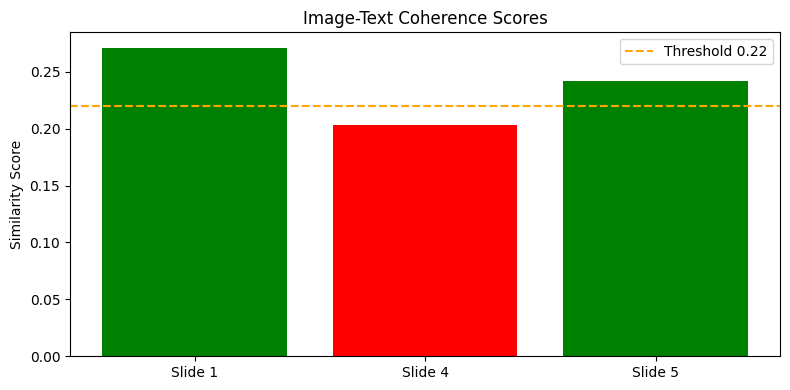

In [19]:
import matplotlib.pyplot as plt

results = []
prs = Presentation(pptx_files[0])
for i, slide in enumerate(prs.slides):
    text = ""
    for shape in slide.shapes:
        if shape.has_text_frame:
            for para in shape.text_frame.paragraphs:
                text += para.text + " "
    text = text.strip()
    image = None
    for shape in slide.shapes:
        if shape.shape_type == 13:
            image_bytes = shape.image.blob
            image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            break
    if not text or image is None:
        continue
    text_emb = get_text_embedding(text)
    image_emb = get_image_embedding(image)
    score = torch.nn.functional.cosine_similarity(
        text_emb, image_emb, dim=1
    ).item()
    results.append((f"Slide {i+1}", score))

labels = [r[0] for r in results]
scores = [r[1] for r in results]
colors = ["green" if s >= 0.22 else "red" for s in scores]

plt.figure(figsize=(8, 4))
plt.bar(labels, scores, color=colors)
plt.axhline(y=0.22, color="orange", linestyle="--", label="Threshold 0.22")
plt.title("Image-Text Coherence Scores")
plt.ylabel("Similarity Score")
plt.legend()
plt.tight_layout()
plt.show()